# Project 2: Data Classification Using AI
**DecodeLabs AI Internship | Batch 2026**  
**Intern:** Harshvardhan Zala  
**Track:** Artificial Intelligence

---

## Architecture: IPO Framework

| Phase | Component | Detail |
|-------|-----------|--------|
| **INPUT** | Iris Dataset | 150 samples, 4 features, 3 classes |
| **INPUT** | Feature Scaling | StandardScaler — Mean=0, Variance=1 |
| **PROCESS** | Train-Test Split | 80% train / 20% test, shuffled |
| **PROCESS** | KNN Algorithm | K-Nearest Neighbors Classifier |
| **OUTPUT** | Confusion Matrix | Per-class prediction breakdown |
| **OUTPUT** | F1 Score | Harmonic mean of Precision & Recall |

> *"We do not write the rules. We provide history, and the machine derives the logic."* — DecodeLabs

---
## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Step 2 — Load Dataset

The Iris dataset has **no header row**, so we assign column names manually.  
4 numeric features + 1 string label column.

In [2]:
df = pd.read_csv(
    '/kaggle/input/datasets/vikrishnan/iris-dataset/iris.data.csv',
    header=None,
    names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
)

df.head(9)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa


### ✅ Checkpoint 1 — Data Load Verification
**Expected:** 150 rows × 5 columns, 4 float features, 1 string label.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

assert df.shape == (150, 5), f"FAIL: Expected (150, 5), got {df.shape}"
assert list(df.columns) == ['sepal_length','sepal_width','petal_length','petal_width','species'], "FAIL: Column names mismatch"
print("\n✅ CHECKPOINT 1 PASSED: 150 rows, 5 columns, correct column names.")

Shape: (150, 5)

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

✅ CHECKPOINT 1 PASSED: 150 rows, 5 columns, correct column names.


---
## Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# --- Null Check ---
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### ✅ Checkpoint 2 — Null Value Check
**Expected:** All zeros (no missing values).

In [5]:
assert df.isnull().sum().sum() == 0, "FAIL: Dataset contains null values!"
print("✅ CHECKPOINT 2 PASSED: No null values found.")

✅ CHECKPOINT 2 PASSED: No null values found.


In [6]:
# --- Class Distribution ---
print("Class distribution:")
print(df['species'].value_counts())

Class distribution:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


### ✅ Checkpoint 3 — Class Balance Check
**Expected:** Exactly 50 samples per class (perfectly balanced dataset).

In [7]:
counts = df['species'].value_counts()
assert len(counts) == 3, "FAIL: Expected 3 classes."
assert (counts == 50).all(), f"FAIL: Classes not balanced. Got:\n{counts}"
print("✅ CHECKPOINT 3 PASSED: 3 balanced classes, 50 samples each.")

✅ CHECKPOINT 3 PASSED: 3 balanced classes, 50 samples each.


In [8]:
# --- Statistical Summary ---
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### ✅ Checkpoint 4 — Feature Range Check
**Expected:** All 4 numeric features present with valid min/max ranges.

In [9]:
desc = df.describe()
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for col in numeric_cols:
    assert col in desc.columns, f"FAIL: Column '{col}' missing from describe."
    assert desc[col]['min'] > 0, f"FAIL: '{col}' has non-positive values."

# Verify known Iris dataset value ranges
assert 4.0 < desc['sepal_length']['min'] < 5.0, "FAIL: sepal_length min out of expected range"
assert desc['sepal_length']['max'] < 8.5, "FAIL: sepal_length max out of expected range"
print("✅ CHECKPOINT 4 PASSED: All feature ranges are valid.")

✅ CHECKPOINT 4 PASSED: All feature ranges are valid.


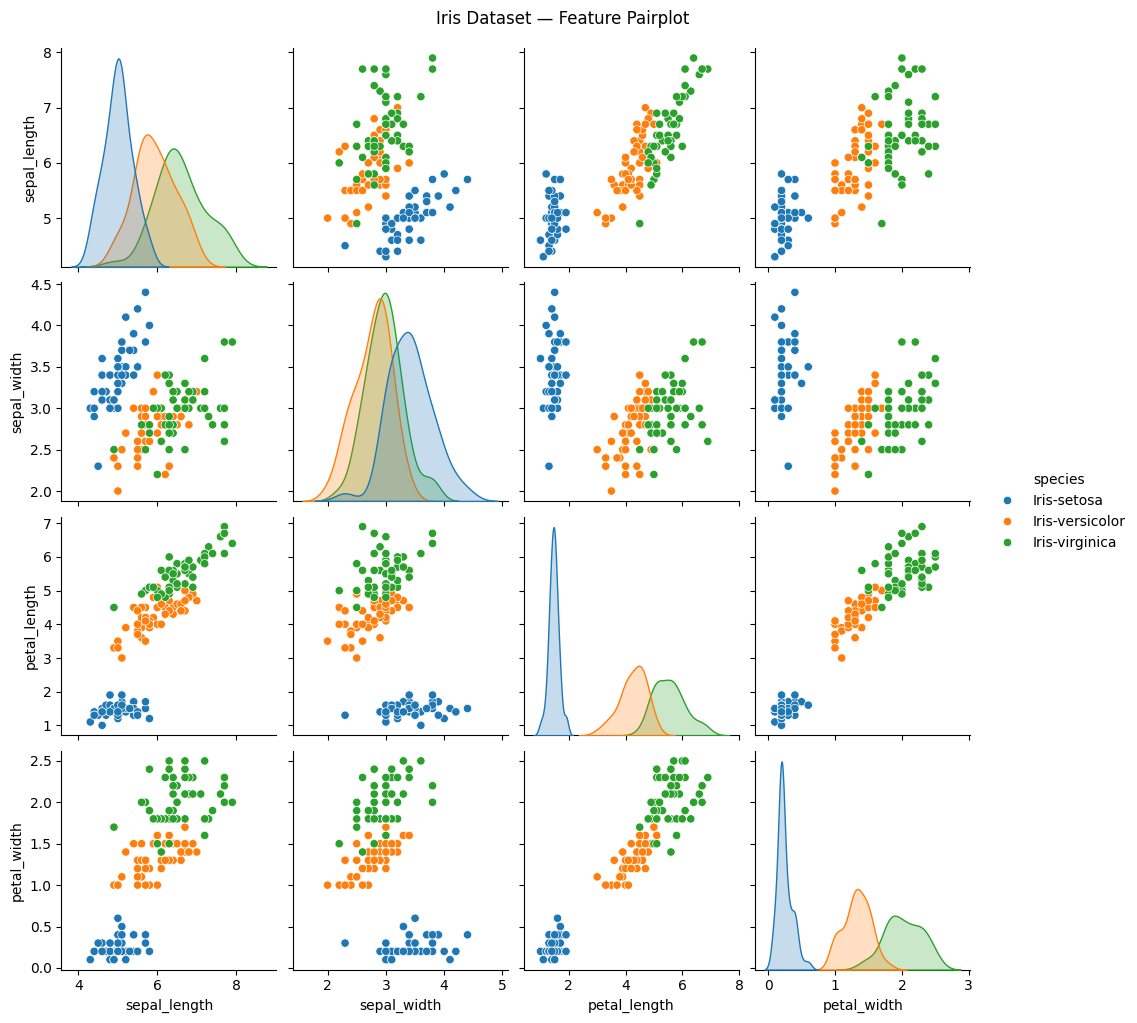

In [10]:
# --- Pairplot: Feature Separability ---
sns.pairplot(df, hue='species', palette='tab10')
plt.suptitle('Iris Dataset — Feature Pairplot', y=1.02)
plt.show()

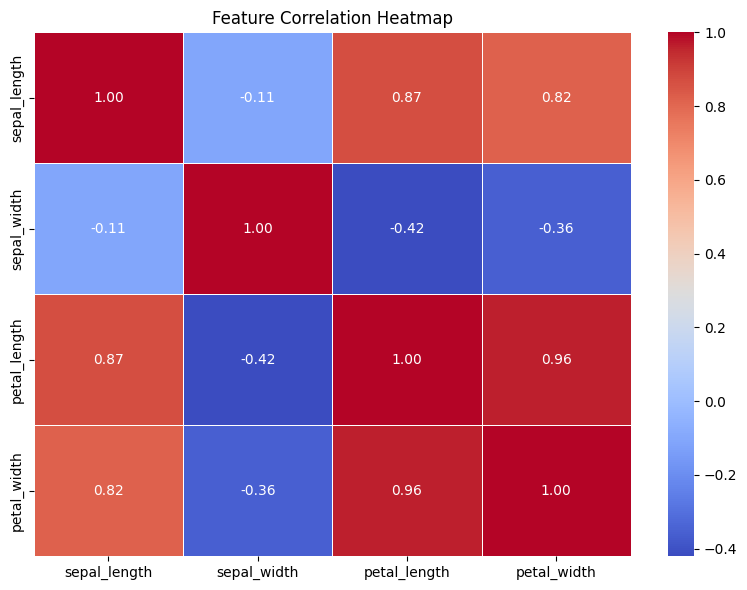

In [11]:
# --- Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', linewidths=0.5
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

/tmp/ipykernel_58/1862398194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='tab10', ax=ax)
/tmp/ipykernel_58/1862398194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='tab10', ax=ax)
/tmp/ipykernel_58/1862398194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=col, palette='tab10', ax=ax)
/tmp/ipykernel_58/1862398194.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

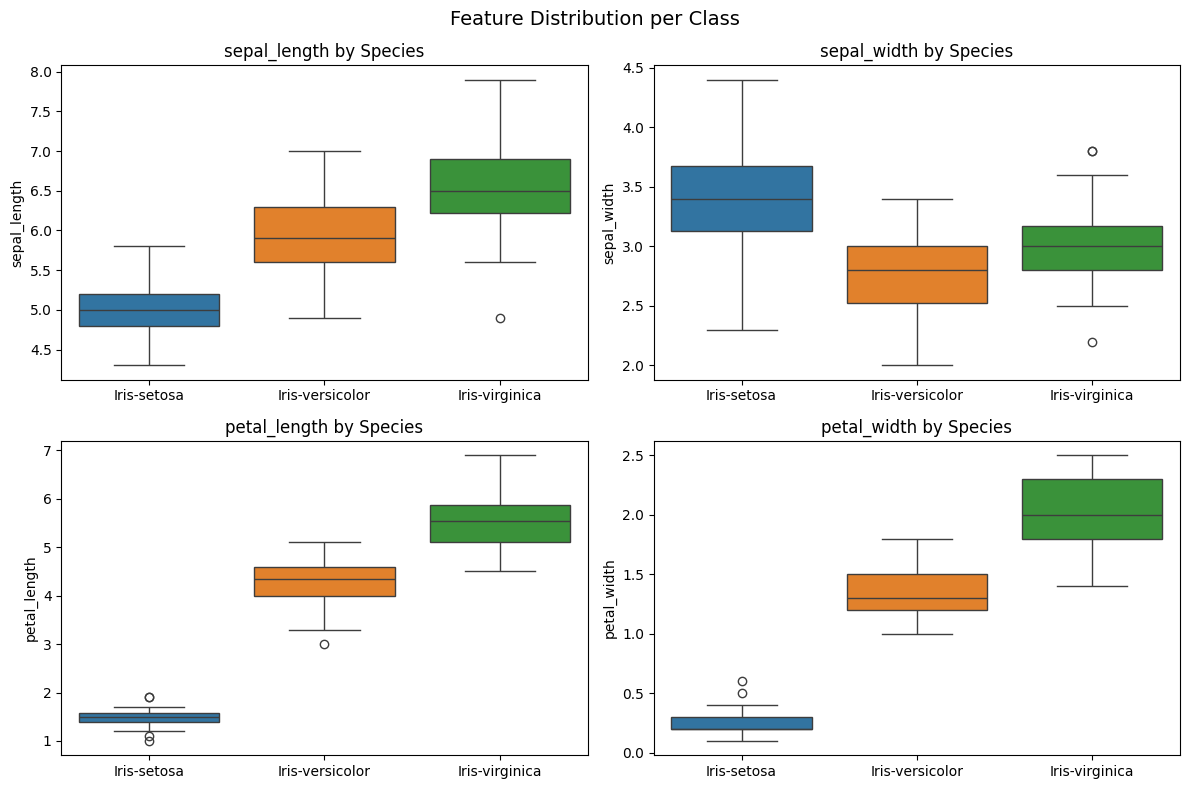

In [12]:
# --- Boxplot: Feature Distribution per Class ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 2][idx % 2]
    sns.boxplot(data=df, x='species', y=col, palette='tab10', ax=ax)
    ax.set_title(f'{col} by Species')
    ax.set_xlabel('')
plt.suptitle('Feature Distribution per Class', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Scaling (The Gatekeeper Rule)

KNN is a **distance-based algorithm**. Without scaling, features with larger ranges  
(e.g., sepal_length 4–8) will dominate features with smaller ranges (e.g., petal_width 0.1–2.5),  
creating a **biased distance metric**.  

`StandardScaler` → Mean = 0, Variance = 1 for all features.

In [13]:
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

X = df[numeric_cols]
y = df['species']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numeric_cols)

print("Scaled feature preview:")
print(X_scaled_df.head())

Scaled feature preview:
   sepal_length  sepal_width  petal_length  petal_width
0     -0.900681     1.032057     -1.341272    -1.312977
1     -1.143017    -0.124958     -1.341272    -1.312977
2     -1.385353     0.337848     -1.398138    -1.312977
3     -1.506521     0.106445     -1.284407    -1.312977
4     -1.021849     1.263460     -1.341272    -1.312977


### ✅ Checkpoint 5 — Scaling Verification
**Expected:** After scaling, each feature should have mean ≈ 0 and std ≈ 1.

In [14]:
for col in numeric_cols:
    col_mean = X_scaled_df[col].mean()
    col_std  = X_scaled_df[col].std()
    assert abs(col_mean) < 1e-9, f"FAIL: Mean of '{col}' is not ~0. Got {col_mean:.6f}"
    assert abs(col_std - 1.0) < 0.05, f"FAIL: Std of '{col}' is not ~1. Got {col_std:.6f}"

print("Scaled feature statistics:")
print(X_scaled_df.describe().loc[['mean','std']].round(4))
print("\n✅ CHECKPOINT 5 PASSED: All features scaled to mean≈0, std≈1.")

Scaled feature statistics:
      sepal_length  sepal_width  petal_length  petal_width
mean       -0.0000      -0.0000        0.0000      -0.0000
std         1.0034       1.0034        1.0034       1.0034

✅ CHECKPOINT 5 PASSED: All features scaled to mean≈0, std≈1.


---
## Step 5 — Train-Test Split (Structural Integrity)

Split: **80% training / 20% test** with shuffle to remove order bias.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set    : {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(pd.Series(y_train).value_counts())

Training set: 120 samples
Test set    : 30 samples

Training class distribution:
species
Iris-versicolor    41
Iris-setosa        40
Iris-virginica     39
Name: count, dtype: int64


### ✅ Checkpoint 6 — Split Verification
**Expected:** 120 train / 30 test, no data leakage, all 3 classes in both sets.

In [16]:
assert X_train.shape[0] == 120, f"FAIL: Expected 120 train samples, got {X_train.shape[0]}"
assert X_test.shape[0]  == 30,  f"FAIL: Expected 30 test samples, got {X_test.shape[0]}"

train_classes = set(pd.Series(y_train).unique())
test_classes  = set(pd.Series(y_test).unique())
assert len(train_classes) == 3, f"FAIL: Not all 3 classes in training set. Found: {train_classes}"
assert len(test_classes)  == 3, f"FAIL: Not all 3 classes in test set. Found: {test_classes}"

# No data leakage check — indices must be disjoint
# (split uses numpy arrays, so we check sizes sum to total)
assert X_train.shape[0] + X_test.shape[0] == 150, "FAIL: Train + Test != 150 (data leakage or loss)"

print("✅ CHECKPOINT 6 PASSED: 120 train / 30 test, 3 classes in each split, no data leakage.")

✅ CHECKPOINT 6 PASSED: 120 train / 30 test, 3 classes in each split, no data leakage.


---
## Step 6 — Tune K: Find Optimal Number of Neighbors

The **Elbow Method** for KNN: test K=1 to K=20 and pick the K with the lowest error rate.  
- **K too small (K=1):** Overfitting — noise-sensitive.  
- **K too large (K=100):** Underfitting — too generic.

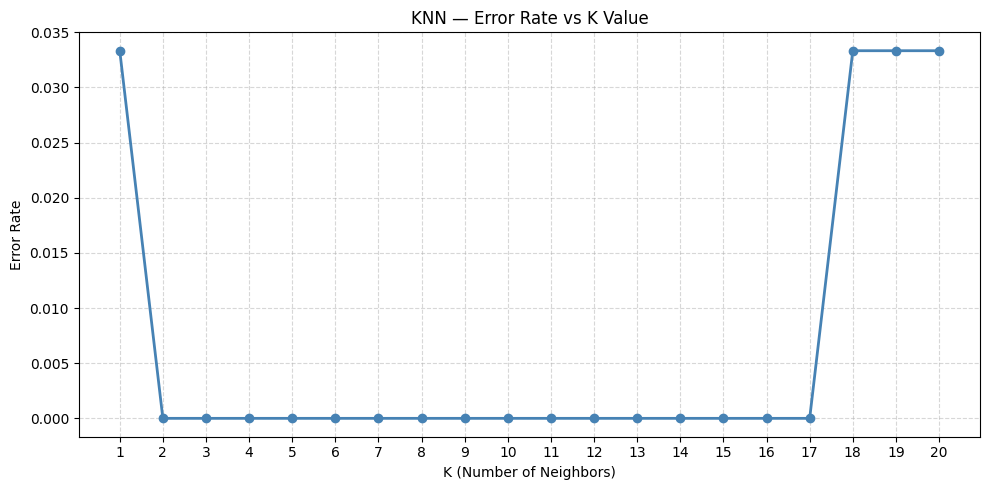

Optimal K: 2  (Error rate: 0.0000)


In [17]:
error_rates = []
k_range = range(1, 21)

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, pred_temp))

# Plot error rate vs K
plt.figure(figsize=(10, 5))
plt.plot(k_range, error_rates, marker='o', color='steelblue', linewidth=2)
plt.title('KNN — Error Rate vs K Value')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Error Rate')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

best_k = k_range[error_rates.index(min(error_rates))]
print(f"Optimal K: {best_k}  (Error rate: {min(error_rates):.4f})")

### ✅ Checkpoint 7 — K Tuning Verification
**Expected:** best_k is between 1 and 20, minimum error rate < 0.1 (this is Iris — it should be very clean).

In [18]:
assert 1 <= best_k <= 20, f"FAIL: best_k={best_k} is outside valid range [1, 20]"
assert min(error_rates) < 0.1, f"FAIL: Min error rate {min(error_rates):.4f} is too high (>0.1)"
print(f"✅ CHECKPOINT 7 PASSED: Best K = {best_k}, Min error rate = {min(error_rates):.4f}")

✅ CHECKPOINT 7 PASSED: Best K = 2, Min error rate = 0.0000


---
## Step 7 — Train KNN Model

Three-step scikit-learn workflow:  
1. **Instantiate** — build the frame  
2. **Fit** — memorize the training map  
3. **Predict** — apply logic to test data

In [19]:
# Instantiate
knn = KNeighborsClassifier(n_neighbors=best_k)

# Fit
knn.fit(X_train, y_train)

# Predict
predictions = knn.predict(X_test)

print("Predictions vs Actual (first 15):")
comparison = pd.DataFrame({
    'Actual'   : list(y_test)[:15],
    'Predicted': list(predictions)[:15]
})
comparison['Correct'] = comparison['Actual'] == comparison['Predicted']
print(comparison.to_string(index=False))

Predictions vs Actual (first 15):
         Actual       Predicted  Correct
Iris-versicolor Iris-versicolor     True
    Iris-setosa     Iris-setosa     True
 Iris-virginica  Iris-virginica     True
Iris-versicolor Iris-versicolor     True
Iris-versicolor Iris-versicolor     True
    Iris-setosa     Iris-setosa     True
Iris-versicolor Iris-versicolor     True
 Iris-virginica  Iris-virginica     True
Iris-versicolor Iris-versicolor     True
Iris-versicolor Iris-versicolor     True
 Iris-virginica  Iris-virginica     True
    Iris-setosa     Iris-setosa     True
    Iris-setosa     Iris-setosa     True
    Iris-setosa     Iris-setosa     True
    Iris-setosa     Iris-setosa     True


### ✅ Checkpoint 8 — Prediction Shape Check
**Expected:** 30 predictions (matching test set size), all values are valid species labels.

In [20]:
valid_labels = {'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

assert len(predictions) == 30, f"FAIL: Expected 30 predictions, got {len(predictions)}"
assert set(predictions).issubset(valid_labels), f"FAIL: Unknown labels in predictions: {set(predictions) - valid_labels}"

print(f"Predictions count : {len(predictions)}")
print(f"Unique labels used: {set(predictions)}")
print("✅ CHECKPOINT 8 PASSED: 30 valid predictions produced.")

Predictions count : 30
Unique labels used: {'Iris-virginica', 'Iris-setosa', 'Iris-versicolor'}
✅ CHECKPOINT 8 PASSED: 30 valid predictions produced.


---
## Step 8 — Output Validation

### Why accuracy alone is not enough
In imbalanced datasets, 99% accuracy can be a *mirage* — the model may just predict the majority class.  
We use **Confusion Matrix** and **F1 Score** to look deeper.

In [21]:
acc    = accuracy_score(y_test, predictions)
f1     = f1_score(y_test, predictions, average='weighted')
report = classification_report(y_test, predictions)
cm     = confusion_matrix(y_test, predictions)

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score (weighted): {f1:.4f}")
print("\nClassification Report:")
print(report)

Accuracy : 1.0000
F1 Score (weighted): 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



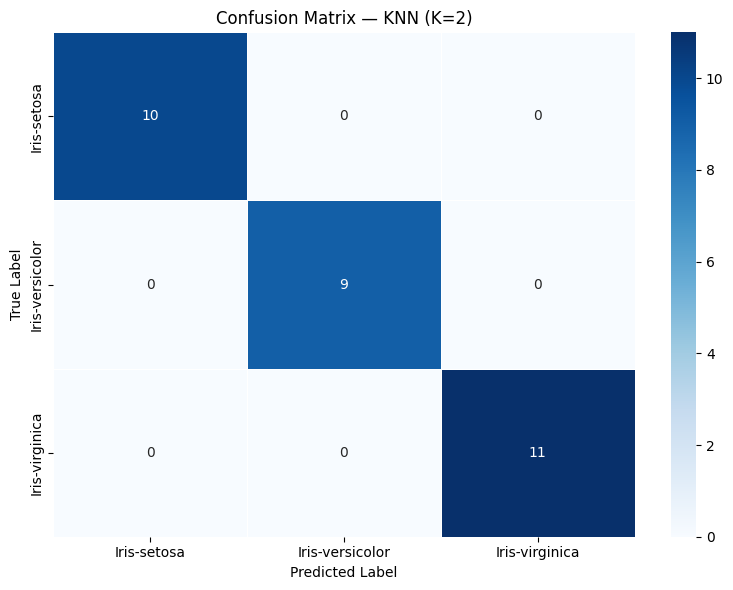

In [22]:
# Confusion Matrix Heatmap
class_labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cmap='Blues', linewidths=0.5
)
plt.title(f'Confusion Matrix — KNN (K={best_k})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### ✅ Checkpoint 9 — Model Performance Validation
**Expected:**  
- Accuracy ≥ 0.90 (Iris is a well-separable dataset)  
- F1 Score ≥ 0.90  
- Confusion matrix is 3×3 with high diagonal values

In [23]:
assert acc >= 0.90, f"FAIL: Accuracy {acc:.4f} below threshold of 0.90"
assert f1  >= 0.90, f"FAIL: F1 Score {f1:.4f} below threshold of 0.90"
assert cm.shape == (3, 3), f"FAIL: Confusion matrix shape {cm.shape} — expected (3, 3)"

# Diagonal dominance: each class must have more TPs than FPs+FNs
for i in range(3):
    tp = cm[i][i]
    row_sum = cm[i].sum()
    assert tp / row_sum >= 0.80, f"FAIL: Class {i} recall below 80%. TP={tp}, Total={row_sum}"

print(f"Accuracy : {acc:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"CM Shape : {cm.shape}")
print("✅ CHECKPOINT 9 PASSED: Model meets performance thresholds.")

Accuracy : 1.0000
F1 Score : 1.0000
CM Shape : (3, 3)
✅ CHECKPOINT 9 PASSED: Model meets performance thresholds.


---
## Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Load Dataset | 150 rows × 5 cols, no nulls |
| 2 | EDA | Balanced classes, clear feature separability |
| 3 | Feature Scaling | StandardScaler → mean=0, std=1 |
| 4 | Train-Test Split | 120 train / 30 test (80/20, shuffled) |
| 5 | Tune K | Elbow method → optimal K selected |
| 6 | Train KNN | fit() + predict() |
| 7 | Evaluate | Accuracy, F1 Score, Confusion Matrix |

### Key Concepts Demonstrated
- **Supervised Learning** — the machine learns from labeled examples
- **Feature Scaling** — critical for distance-based algorithms like KNN
- **Train-Test Split** — prevents overfitting evaluation
- **K Tuning (Elbow)** — balances overfitting vs underfitting
- **F1 Score over Accuracy** — robust metric for balanced and imbalanced data
- **Confusion Matrix** — per-class breakdown of model decisions

> *DecodeLabs | Batch 2026 | Artificial Intelligence Track*